# HealthBot: AI-Powered Patient Education System

This notebook implements a **LangGraph** workflow that:
1. Healthbot asks the patient for a health topic to learn
2. Searches Tavily for reputable sources, upto date medical information
3. Summarizes the results into patient-friendly language using `only` the search results
4. Presents the summary and waits for the patient to take a quiz
5. Generates a one-question comprehension quiz from the summary and present
6. Takes the patient's answer and grades it with a letter grade with a citation-based justification
7. Lets the patient loop to a new topic (with a full state reset) or exit



In [33]:
# --- Imports ---
import os
import re
from typing import TypedDict
from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_community.tools.tavily_search import TavilySearchResults
from langgraph.graph import StateGraph, END


## 1. Load API Keys

As the `config.env` contains our API Keys load it into our environment.

```
GOOGLE_API_KEY="AIza..."
TAVILY_API_KEY="tvly-..."
```


In [34]:
# Load in the Gemini key and Tavily key.
load_dotenv("config.env")

if not os.getenv("GOOGLE_API_KEY"):
    raise ValueError("GOOGLE_API_KEY is missing check config.env file")

if not os.getenv("TAVILY_API_KEY"):
    raise ValueError("TAVILY_API_KEY is missing check config.env file")

print("API keys loaded successfully.")

API keys loaded successfully.


## 2. Configure the Model and Tavily Search Tool

- `llm` represents the Gemini chat model that is used for summarizing content, generating quiz, grading.
- `tavily_tool` is used to perform web searches through the Tavily API.


In [35]:
llm = ChatGoogleGenerativeAI(model="gemini-3.5-flash-lite")

tavily_tool = TavilySearchResults(
    max_results=5,
    search_depth="advanced",
    include_domains=["mayoclinic.org", "nih.gov", "cdc.gov", "medlineplus.gov"],
)

tavily_tool_broad = TavilySearchResults(
    max_results=5,
    search_depth="advanced",
)
# This is a helper function to extract text from the Gemini response, which can be in different formats and normalize to a single string.
def _extract_text(response) -> str:
    """Gemini may return the response content either as a string or as a list of parts. 
       This function handles both formats and converts them 
       into one clean string that can be used by the other nodes."""

    content = response.content
    if isinstance(content, str):
        return content.strip()
    if isinstance(content, list):
        parts = []
        for item in content:
            if isinstance(item, str):
                parts.append(item)
            elif isinstance(item, dict):
                parts.append(item.get('text', '') or item.get('content', ''))
            else:
                parts.append(str(item))
        return "".join(parts).strip()
    return str(content).strip()

# A simple test to check if the Gemini and Tavily connections are working.
test = llm.invoke("Reply with the single word: OK")
print("Gemini check:", _extract_text(test))

test_search = tavily_tool.invoke({"query": "test connection health topic diabetes"})
print("Tavily check: got a response of type", type(test_search).__name__)


Gemini check: OK
Tavily check: got a response of type list


## 3. Define the LangGraph State

The state keeps track of the information shared between all the nodes. Each node can read the required data from the state and add its results, which can then be used by the next nodes and the final grading step.


In [36]:
# --- State Definition ---
class HealthBotState(TypedDict):
    topic: str                  # the health topic the patient wants to learn about
    search_results: str         # search results from Tavily, in plain text 
    summary: str                # patient-friendly summary generated from search_results
    quiz_question: str          # single comprehension quiz question generated from summary
    user_answer: str            # patient's answer to the quiz question
    grade: str                  # letter grade (A, B, C, D, F)
    feedback: str               # explanation for the grade, with citations
    continue_session: bool      # whether the patient wants to learn about another topic or exit
    error: str                  # error message if something went wrong, otherwise empty string
    topic_classification: str   # "MEDICAL", "NOT_MEDICAL", "UNCLEAR", or ""

# function to build a fresh/blank state — also used to reset state between topics.
def build_initial_state() -> HealthBotState:
    return {
        "topic": "",
        "search_results": "",
        "summary": "",
        "quiz_question": "",
        "user_answer": "",
        "grade": "",
        "feedback": "",
        "continue_session": False,
        "error": "",
        "topic_classification": "",
    }


## 4. Define the Nodes

In [37]:
# Node 1: Ask the patient for a topic 
def get_topic_node(state: HealthBotState) -> HealthBotState:
    print("\n" + "=" * 30)
    print("    Welcome to HealthBot!")
    print("=" * 30)
    print("Let's get started with your learning session.\n")

    topic = input("Enter a health topic or medical condition: ")
    print(f"Topic selected: {topic.upper()}")
    
    print("Let's begin learning!")
    state["topic"] = topic
    return state


# prompt to classify the user's input as a medical topic or not.    
CLASSIFY_PROMPT = """You are a strict topic classifier for a healthcare patient-education chatbot.

Decide whether the user's input below is a request to learn about a medical
condition, disease, symptom, treatment, medication, procedure, or a general
health / wellness / patient-education topic.

Respond with EXACTLY ONE WORD, nothing else:
- MEDICAL     -> if it is clearly a health, medical, or patient-education topic.
- NOT_MEDICAL -> if it is clearly unrelated to health/medical topics (e.g. cars, cooking, sports scores, coding, celebrities).
- UNCLEAR     -> if you cannot confidently tell what the user means (gibberish, a bare number, a single ambiguous word, etc).

User input: "{topic}"

Respond with only one word: MEDICAL, NOT_MEDICAL, or UNCLEAR.
"""
# guardrail node to classify the topic before searching Tavily. This prevents the bot from wasting time searching for non-medical topics.
def classify_topic_node(state: HealthBotState) -> HealthBotState:
    prompt = CLASSIFY_PROMPT.format(topic=state["topic"])
    raw = _extract_text(llm.invoke(prompt)).strip().upper()

    if "NOT_MEDICAL" in raw or "NOT MEDICAL" in raw:
        classification = "NOT_MEDICAL"
    elif "UNCLEAR" in raw:
        classification = "UNCLEAR"
    elif "MEDICAL" in raw:
        classification = "MEDICAL"
    else:
        classification = "UNCLEAR"

    state["topic_classification"] = classification
    return state

# function to determine the next route in the graph based on the topic classification.
def route_after_classification(state: HealthBotState) -> str:
    return "medical" if state.get("topic_classification") == "MEDICAL" else "rejected"

# handle the case where the topic is rejected (not medical or unclear) and provide feedback to the user.
def topic_rejected_node(state: HealthBotState) -> HealthBotState:
    print("\n" + "=" * 70)
    if state.get("topic_classification") == "NOT_MEDICAL":
        print(f"    It looks like \"{state['topic']}\" is not related to a health or medical topic.")
        print("    HealthBot is designed to help with topics such as:")
        print("    • Medical conditions")
        print("    • Symptoms")
        print("    • Treatments and medications")
        print("    • General health and wellness")
        print("\nPlease try entering a health-related topic.")
    else:  
        print(f"    I'm not sure what you mean by \"{state['topic']}\".")
        print("    Could you try explaining the health topic a little more clearly?")
        print("    For example, you could enter:")
        print("    • Diabetes")
        print("    • High blood pressure")
        print("    • Asthma")
        print("    • Recovery after knee surgery")
    print("=" * 70)
    return state


In [38]:
# Helper function to normalize Tavily output into a single string, regardless of the shape of the response.
def _format_tavily_results(results) -> str:
    if isinstance(results, dict) and "results" in results:
        results = results["results"]

    if isinstance(results, str):
        return results

    if isinstance(results, list):
        parts = []
        for r in results:
            if isinstance(r, dict):
                parts.append(f"Source: {r.get('url', 'unknown')}\n{r.get('content', '')}")
            else:
                parts.append(str(r))
        return "\n\n".join(parts)

    return str(results)


# error content pattern to detect if Tavily returned an error message instead of valid search results.
_ERROR_CONTENT_PATTERN = re.compile(
    r"(httperror|client error|server error|rate limit|quota exceeded|"
    r"unauthorized|forbidden|failed to fetch|connection error|"
    r"\btimed?[\s_-]?out\b|\b[4-5]\d{2}\b\s*(client|server)?\s*error)",
    re.IGNORECASE,
)

# function to check if the Tavily output looks like an error message instead of valid search results.
def _looks_like_error_content(text: str) -> bool:
    return bool(_ERROR_CONTENT_PATTERN.search(text))

# Node 2: Search Tavily for reputable medical info
def search_tavily_node(state: HealthBotState) -> HealthBotState:
    topic = state["topic"]
    query = f"{topic} symptoms causes treatment"
    print(f"\nSearching reliable medical sources for information on \"{topic.upper()}\"\n")

    try:
        results = tavily_tool.invoke({"query": query})
        combined = _format_tavily_results(results)

        if not combined.strip():
            # Broaden to the open web if the reputable-domain-only search comes up empty
            results = tavily_tool_broad.invoke({"query": f"{topic} medical information symptoms treatment"})
            combined = _format_tavily_results(results)

        if not combined.strip():
            state["error"] = "no_results"
        elif _looks_like_error_content(combined):
            print(f"[Tavily returned error-shaped content]: {combined[:200]}")
            state["error"] = "search_failed"
        else:
            state["search_results"] = combined

    except Exception as e:
        print(f"[Tavily error details]: {e}")
        state["error"] = "search_failed"

    return state


In [39]:
# prompt to summarize the search results in patient-friendly language, using only the information from the search results.
SUMMARY_PROMPT = """You are a patient education assistant working for a hospital.

Using ONLY the medical search results provided below — do not use any outside
knowledge or make anything up — write a clear, patient-friendly summary of the
topic: "{topic}".

Requirements:
- Write 3 to 4 paragraphs.
- Use plain, non-technical language a patient without a medical background can understand.
- Cover what it is, common causes/symptoms (if present in the sources), and
  general treatment or management information found in the sources.
- Do not include any information that is not supported by the search results below.

Search results:
{search_results}
"""
# Node 3: Summarize the search results in patient-friendly language
def summarize_node(state: HealthBotState) -> HealthBotState:
    prompt = SUMMARY_PROMPT.format(topic=state["topic"], search_results=state["search_results"])
    response = llm.invoke(prompt)
    state["summary"] = _extract_text(response)
    return state


In [40]:
# Node 4: Present the summary to the patient 
def present_summary_node(state: HealthBotState) -> HealthBotState:
    print("=" * 30)
    print(f"  LEARNING ABOUT: {state['topic'].upper()}")
    print("=" * 30)
    print(state["summary"])
    input("\n Take a moment to go through the information. Press Enter when you're ready for a short quiz...")
    return state


In [41]:
# prompt to generate a single comprehension question based ONLY on the summary, without requiring any outside knowledge.
QUIZ_PROMPT = """Based ONLY on the summary below, write exactly ONE comprehension
question a patient could answer after reading it. The question must be answerable
using only the information in the summary — do not require outside knowledge.

Return ONLY the question text, with no preamble, numbering, or answer key.

Summary:
{summary}
"""
# Node 5: Generate a one-question quiz from the summary only
def generate_quiz_node(state: HealthBotState) -> HealthBotState:
    prompt = QUIZ_PROMPT.format(summary=state["summary"])
    response = llm.invoke(prompt)
    state["quiz_question"] = _extract_text(response)
    return state


In [42]:
# Node 6: Present the quiz question and collect the patient's answer 
def present_quiz_node(state: HealthBotState) -> HealthBotState:
    print("\n" + "=" * 30)
    print("    QUICK KNOWLEDGE CHECK")
    print("=" * 30)
    print(state["quiz_question"])
    answer = input("\n Enter your answer: ")
    print("\n" + "=" * 30)
    print("        YOUR ANSWER")
    print("=" * 30)
    print(answer)
    state["user_answer"] = answer
    return state


In [43]:
# prompt to grade the patient's answer to the quiz question, using ONLY the summary as the source of truth.
GRADE_PROMPT = """You are grading a patient's answer to a comprehension question.
Use ONLY the summary below as your source of truth — do not use outside knowledge.

Summary:
{summary}

Quiz question:
{quiz_question}

Patient's answer:
{user_answer}

Respond in exactly this format:
Grade: <a single letter grade: A, B, C, D, or F>
Explanation: <a short explanation of why this grade was given, including a direct
citation or paraphrase from the summary that supports the correct answer>
"""
# Node 7: Grade the answer using ONLY the summary as the source of truth
def grade_answer_node(state: HealthBotState) -> HealthBotState:
    prompt = GRADE_PROMPT.format(
        summary=state["summary"],
        quiz_question=state["quiz_question"],
        user_answer=state["user_answer"],
    )
    response = _extract_text(llm.invoke(prompt))

    grade = "N/A"
    explanation = response
    for line in response.splitlines():
        if line.lower().startswith("grade:"):
            grade = line.split(":", 1)[1].strip()
        elif line.lower().startswith("explanation:"):
            explanation = line.split(":", 1)[1].strip()

    state["grade"] = grade
    state["feedback"] = explanation
    return state


In [44]:
# Node 8: Present the grade and feedback to the patient
def present_grade_node(state: HealthBotState) -> HealthBotState:
    print("\n" + "=" * 30)
    print("        YOUR RESULT")
    print("=" * 30)
    print(f"Grade: {state['grade']}")
    print(f"\nFeedback: {state['feedback']}")
    print("\nThanks for using HealthBot! Hope you found the session helpful.")
    print("=" * 70)
    return state


In [45]:
# Node 9: Ask if the patient wants to continue with a new topic
def ask_continue_node(state: HealthBotState) -> HealthBotState:
    choice = input("\nWould you like to learn about another topic? (yes/no): ").strip().lower()
    state["continue_session"] = choice.startswith("y")
    return state


# Node 10: Reset state before looping back whcih clears previous session data to protect privacy and ensure accuracy for the next topic.
def reset_state_node(state: HealthBotState) -> HealthBotState:
    print("\nStarting a new topic — clearing previous session data...\n")
    return build_initial_state()


# Routing function for the conditional edge 
def route_continue(state: HealthBotState) -> str:
    return "reset" if state["continue_session"] else "end"


# function to display an error message to the user if the search failed or returned no usable results.
def display_search_error_node(state: HealthBotState) -> HealthBotState:
    print("\n" + "=" * 70)
    error = state.get("error")
    if error == "search_failed":
        print("   Sorry, I couldn't connect to the medical search service right now.")
        print("   This may be due to a temporary connection problem or")
        print("   an issue with the search service.")
        print("\n Please try again in a little while.")
    elif error == "summary_unavailable":
        print("   I couldn't find enough reliable information about that topic.")
        print("   Try entering a more specific health topic.")
        print("   For example: 'type 2 diabetes', 'asthma symptoms',")
        print("   or 'recovery after knee surgery'.")
    else:
        print("   I wasn't able to find reliable information for that topic.")
        print("   Please check the topic and try entering it again.")
    print("=" * 70)
    return state

# Routing function for the conditional edge after search
def route_after_search(state: HealthBotState) -> str:
    return "error" if state.get("error") else "ok"

# a list of phrases that indicate the summary generation failed, which is used to detect if the model was unable to produce a valid summary.
_SUMMARY_FAILURE_PHRASES = [
    "i cannot", "i can't", "i am unable", "i'm unable",
    "cannot generate a summary", "cannot provide a summary",
    "cannot create a summary", "unable to generate a summary",
    "there is no mention", "does not contain", "no information",
    "unable to access", "technical error", "i am sorry", "i'm sorry",
    "not found in the provided", "no relevant information",
    "without additional information", "no such topic",
]

# function to check if the summary indicates a failure to generate a valid summary, based on the presence of certain phrases.
def _summary_indicates_failure(summary: str) -> bool:
    lowered = summary.lower()
    return any(phrase in lowered for phrase in _SUMMARY_FAILURE_PHRASES)

#function to validate the summary and set an error state if it indicates a failure to generate a valid summary.
def validate_summary_node(state: HealthBotState) -> HealthBotState:
    if _summary_indicates_failure(state["summary"]):
        state["error"] = "summary_unavailable"
    return state

# Routing function for the conditional edge after summary
def route_after_summary(state: HealthBotState) -> str:
    return "error" if state.get("error") else "ok"


## 5. Build the LangGraph Workflow

The workflow connects all the nodes and defines how the HealthBot moves from one step to the next. It also uses conditional paths to handle cases such as invalid topics, search errors, and continuing or ending the session.

Once all the nodes and connections are defined, the workflow is compiled into an executable application.


In [46]:
workflow = StateGraph(HealthBotState)

workflow.add_node("get_topic", get_topic_node)
workflow.add_node("classify_topic", classify_topic_node)
workflow.add_node("topic_rejected", topic_rejected_node)
workflow.add_node("validate_summary", validate_summary_node)
workflow.add_node("search_tavily", search_tavily_node)
workflow.add_node("summarize", summarize_node)
workflow.add_node("present_summary", present_summary_node)
workflow.add_node("generate_quiz", generate_quiz_node)
workflow.add_node("present_quiz", present_quiz_node)
workflow.add_node("grade_answer", grade_answer_node)
workflow.add_node("present_grade", present_grade_node)
workflow.add_node("ask_continue", ask_continue_node)
workflow.add_node("reset_state", reset_state_node)

workflow.set_entry_point("get_topic")

workflow.add_edge("get_topic", "classify_topic")
workflow.add_conditional_edges(
    "classify_topic",
    route_after_classification,
    {"medical": "search_tavily", "rejected": "topic_rejected"},
)
workflow.add_edge("topic_rejected", "get_topic")
workflow.add_node("display_search_error", display_search_error_node)

workflow.add_conditional_edges(
    "search_tavily",
    route_after_search,
    {"error": "display_search_error", "ok": "summarize"},
)
workflow.add_edge("display_search_error", END)
workflow.add_edge("summarize", "validate_summary")
workflow.add_conditional_edges(
    "validate_summary",
    route_after_summary,
    {"error": "display_search_error", "ok": "present_summary"},
)
workflow.add_edge("present_summary", "generate_quiz")
workflow.add_edge("generate_quiz", "present_quiz")
workflow.add_edge("present_quiz", "grade_answer")
workflow.add_edge("grade_answer", "present_grade")
workflow.add_edge("present_grade", "ask_continue")

workflow.add_conditional_edges(
    "ask_continue",
    route_continue,
    {"reset": "reset_state", "end": END},
)
workflow.add_edge("reset_state", "get_topic")

app = workflow.compile()
print("Graph compiled successfully.")


Graph compiled successfully.


### Visualize the graph

The graph gives a clear view of how the different nodes are connected and how the HealthBot moves through each step of the workflow. It also makes the conditional paths and decision points easier to understand.


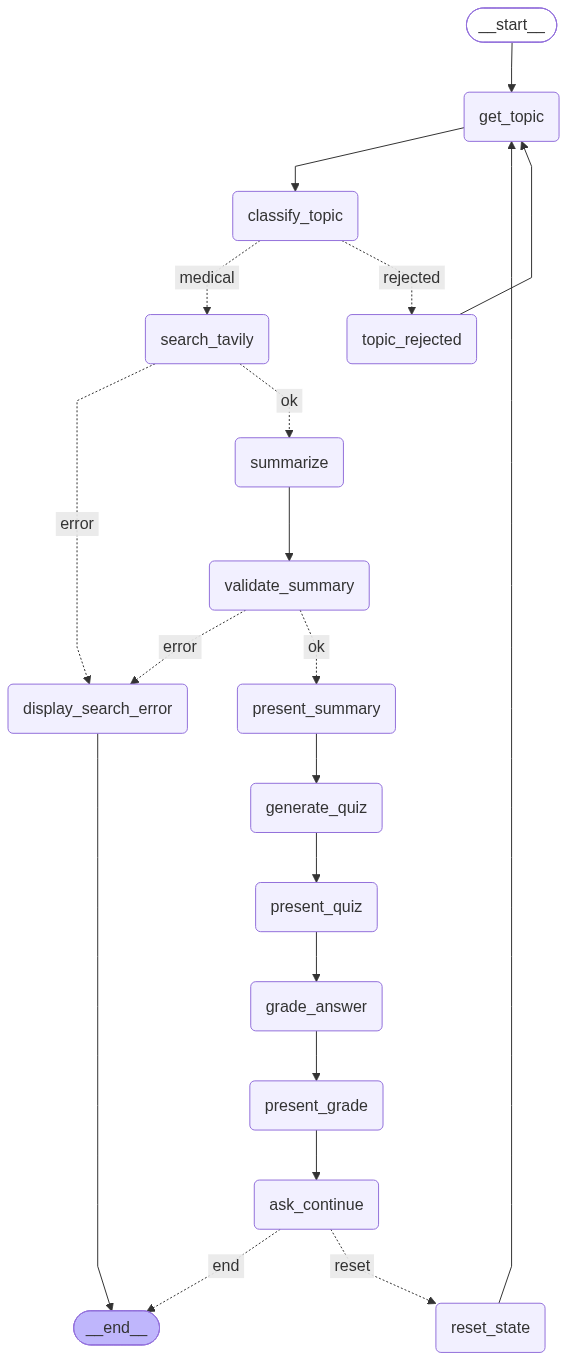

In [47]:
try:
    from IPython.display import Image, display
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception as e:
    print("Graph visualization skipped:", e)


## 6. Run the HealthBot

Once the workflow is compiled, the HealthBot is ready to run. The application starts with the initial state and follows the workflow step by step based on the user's input and the decisions made along the way..


In [48]:
initial_state = build_initial_state()

final_state = app.invoke(initial_state, config={"recursion_limit": 100})

print("\nSession ended. Thanks for using HealthBot!")
print("\nIf you have any other questions, feel free to reach out. Take care and stay healthy!")



    Welcome to HealthBot!
Let's get started with your learning session.

Topic selected: BIRTH789RATE988ININDIA09
Let's begin learning!

Searching reliable medical sources for information on "BIRTH789RATE988ININDIA09"

  LEARNING ABOUT: BIRTH789RATE988ININDIA09
Based on the provided search results, India has experienced a transition in fertility over time. Data from the National Family Health Survey showed that the national total fertility rate fell to 2.7, down from averages of around 6.0 children per woman in the 1950s and early 1960s, and 4.7 in 1976–81. However, these national averages mask significant regional differences across the country. For example, state fertility levels have been recorded as high as 4.0 births per woman in Bihar, while dropping as low as 1.8 in Andhra Pradesh and Goa. 

Additionally, the provided sources note that Indian people live among certain risk factors for birth defects, such as the universality of marriage, high fertility rates, and a large number 